<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

In [19]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

2.9.0+cu126


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

1)Camera and photo apps use [computer vision to enhance](https://machinelearning.apple.com/research/panoptic-segmentation) and sort images.

2)Modern cars use [computer vision](https://youtu.be/j0z4FweCy4M?t=2989) to avoid other cars and stay within lane lines.

3)Manufacturers use computer vision to identify defects in various products.


## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

overfitting occurs when a model fits too closely or even exactly to its training data, such that it can’t make accurate predictions or conclusions from any data other than the training data.
to sum up the model is complex and learns  the noise instead of learning pattern.


* train data==> peform very well
* test data==> perform poorly

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

* Early stopping:  this method seeks to pause training before the model starts learning the noise within the model.

* Train with more data: Expanding the training set to include more data can increase the accuracy of the model by providing more opportunities to parse out the dominant relationship among the input and output variables . EX:
data agumentation ,
feature selection

* Ensemble methods: Ensemble learning methods are made up of a set of classifiers—e.g. decision trees—and their predictions are aggregated to identify the most popular result

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

In [3]:
# done

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [4]:
import torch
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 20.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 310kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]


## 6. Visualize at least 5 different samples of the MNIST training dataset.

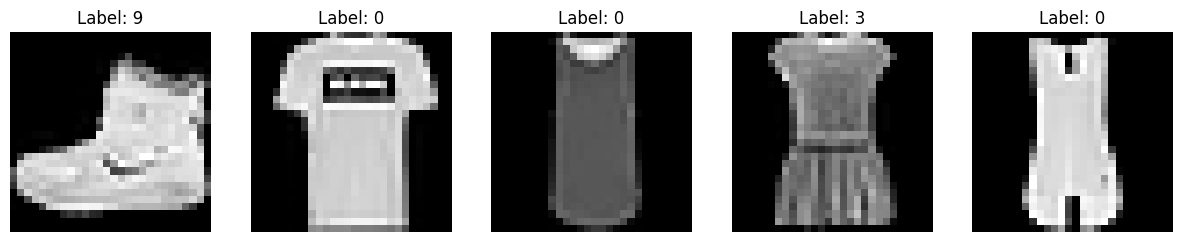

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i in range(5):
  image, label = train_data[i]
  plt.subplot(1, 5, i + 1)
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(f"Label: {label}")
  plt.axis("off")

plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [6]:
from torch.utils.data import DataLoader
from torch import nn
batch_size=32
train_dataLoader=DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_dataLoader=DataLoader(test_data,batch_size=batch_size,shuffle=True)
train_features_batch, train_labels_batch = next(iter(train_dataLoader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [7]:
flatten_model = nn.Flatten()

x = train_features_batch[0]


output = flatten_model(x)


print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

print(x)
print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [8]:
from torch import nn
class FashionMNISTModelV2(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,out_features=output_shape)
    )
  def forward(self,x):
   x=self.block_1(x)
   x=self.block_2(x)
   x=self.classifier(x)
   return x
torch.manual_seed(42)
model_2=FashionMNISTModelV2(input_shape=1,hidden_units=10,output_shape=len(train_data.classes)).to(device)


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [10]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):

        X, y = X.to(device), y.to(device)


        y_pred = model(X)


        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))


        optimizer.zero_grad()


        loss.backward()


        optimizer.step()


    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)


            test_pred = model(X)


            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )


        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

# Define accuracy_fn here
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [14]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [15]:
# Measure time on Gpu
from tqdm.auto import tqdm
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataLoader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataLoader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.57780 | Train accuracy: 79.04%
Test loss: 0.38589 | Test accuracy: 85.77%

Epoch: 1
---------
Train loss: 0.35428 | Train accuracy: 87.12%
Test loss: 0.38167 | Test accuracy: 86.14%

Epoch: 2
---------
Train loss: 0.31571 | Train accuracy: 88.61%
Test loss: 0.31317 | Test accuracy: 88.63%

Epoch: 3
---------
Train loss: 0.29692 | Train accuracy: 89.18%
Test loss: 0.31231 | Test accuracy: 88.66%

Epoch: 4
---------
Train loss: 0.28127 | Train accuracy: 89.94%
Test loss: 0.30202 | Test accuracy: 89.16%

Train time on cuda: 58.531 seconds


In [17]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataLoader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataLoader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.27156 | Train accuracy: 90.27%
Test loss: 0.29907 | Test accuracy: 89.18%

Epoch: 1
---------
Train loss: 0.26398 | Train accuracy: 90.46%
Test loss: 0.29309 | Test accuracy: 89.34%

Epoch: 2
---------
Train loss: 0.25688 | Train accuracy: 90.67%
Test loss: 0.29016 | Test accuracy: 89.44%

Epoch: 3
---------
Train loss: 0.24976 | Train accuracy: 90.94%
Test loss: 0.29143 | Test accuracy: 89.62%

Epoch: 4
---------
Train loss: 0.24642 | Train accuracy: 91.09%
Test loss: 0.28763 | Test accuracy: 89.73%

Train time on cpu: 217.068 seconds


In [18]:
#Train time on cuda: 58.531 seconds

#Train time on cpu: 217.068 seconds

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [25]:
def make_predictions(model:torch.nn.Module, data:list,device:torch.device=device,):
  pred_probs=[]
  model.eval()
  # Move the model to the target device before inference
  model.to(device)
  with torch.inference_mode():
    for sample in data:
      sample=torch.unsqueeze(sample,dim=0)
      sample=sample.to(device)
      pred_logit=model(sample)
      pred_prob=torch.softmax(pred_logit,dim=1)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [36]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

In [37]:
pred_probs=make_predictions(model=model_2,data=test_samples)

In [38]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [42]:
pred_classes = pred_probs.argmax(dim=2).squeeze()
pred_classes

tensor([5, 1, 7, 4, 3, 6, 4, 7, 1])

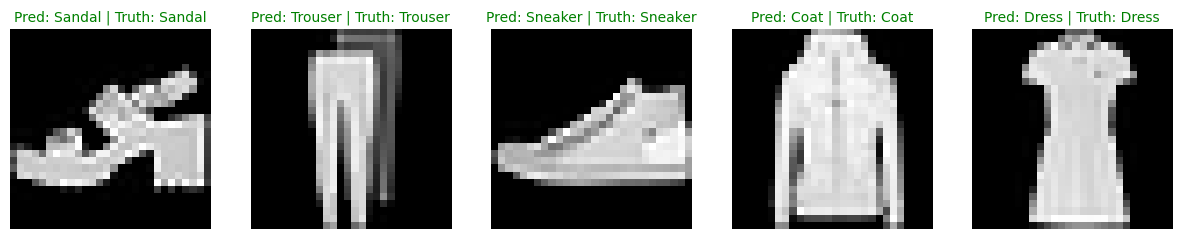

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for i in range(5):
    # image.squeeze() is used to remove the channel dimension (which is 1 for grayscale images).
    # torchvision.transforms.ToTensor() converts images to [C, H, W], where C=1 for grayscale.
    # matplotlib.pyplot.imshow() expects grayscale images to be [H, W].
    # notes to remind me
    image,true_label = test_samples[i].squeeze() , test_labels[i]


    predicted_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]

    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap="gray")
    title_text = f"Pred: {predicted_label} | Truth: {truth_label}"
    if predicted_label == truth_label:
      plt.title(title_text, fontsize=10, c="g")
    else:
      plt.title(title_text, fontsize=10, c="r")
    plt.axis("off")

plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [47]:
from tqdm.auto import tqdm

y_preds=[]
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataLoader, desc="Making predictions"):

    X, y = X.to(device), y.to(device)

    y_logit = model_2(X)

    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [48]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.4 MB/s eta 0:00:00
mlxtend version: 0.23.4


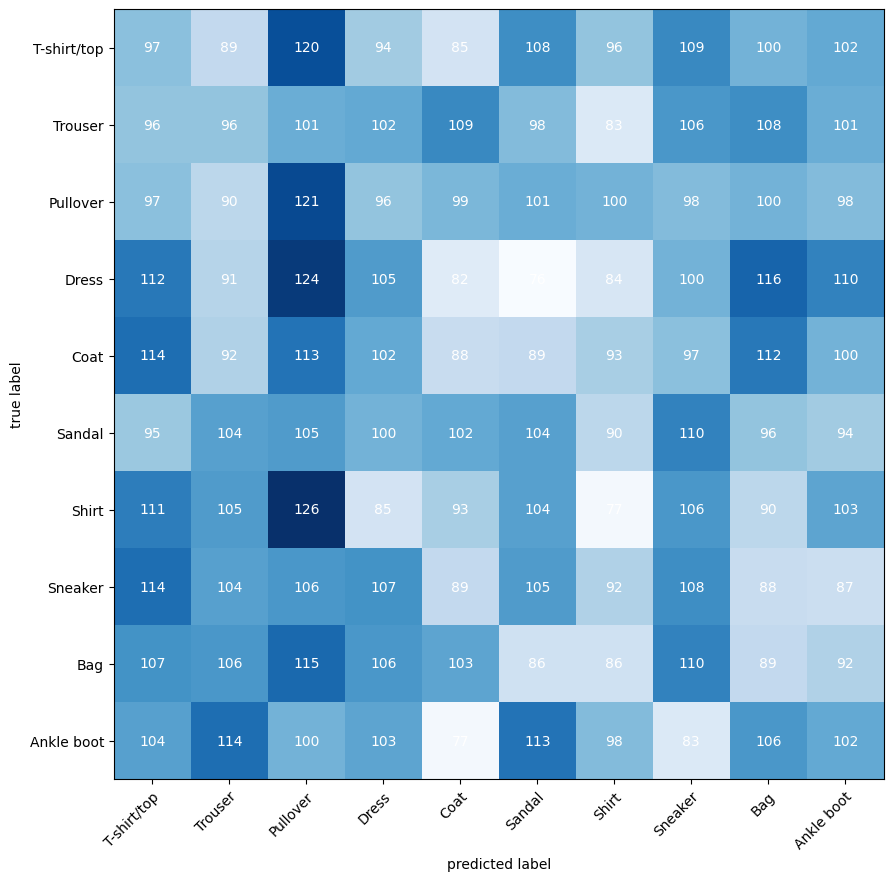

In [49]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import numpy as np
conv_matrix=ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = conv_matrix(preds=y_pred_tensor,
                         target=test_data.targets)
fig,ax=plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                             class_names=class_names,
                             figsize=(10,10))

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [62]:
rand_tensor= torch.randn(1, 3, 64, 64)
rand_tensor.shape

conv_1=nn.Conv2d(in_channels=3,out_channels=8,kernel_size=3,stride=1,padding=1)
y=conv_1(rand_tensor)
print("kernel=3 output shape:",y.shape)



kernel=3 output shape: torch.Size([1, 8, 64, 64])


In [64]:
conv5 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5,stride=1,padding=1)
y5 = conv5(rand_tensor)
print("kernel=5 output shape:", y5.shape)

kernel=5 output shape: torch.Size([1, 8, 62, 62])


In [65]:
conv7 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=7)
y7 = conv7(rand_tensor)
print("kernel=7 output shape:", y7.shape)
# hidden units=num_of_kernals==> note

kernel=7 output shape: torch.Size([1, 8, 58, 58])


# we notice that The output spatial size shrinks when kernel_size increases according to this law:
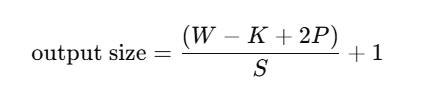

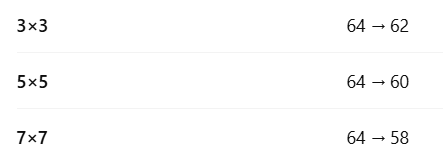

In [ ]:
# we notice that The output spatial size shrinks when kernel_size increases

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [66]:
model_2.eval()
misclassified_images = []
misclassified_preds = []
misclassified_labels = []
with torch.inference_mode():
  for i in range(len(test_data)):
    image,label=test_data[i]
    image = image.unsqueeze(0).to(device)

    logits=model_2(image)
    pred_label=torch.argmax(logits,dim=1).item()
    if pred_label!=label:
      misclassified_images.append(image)
      misclassified_preds.append(pred_label)
      misclassified_labels.append(label)

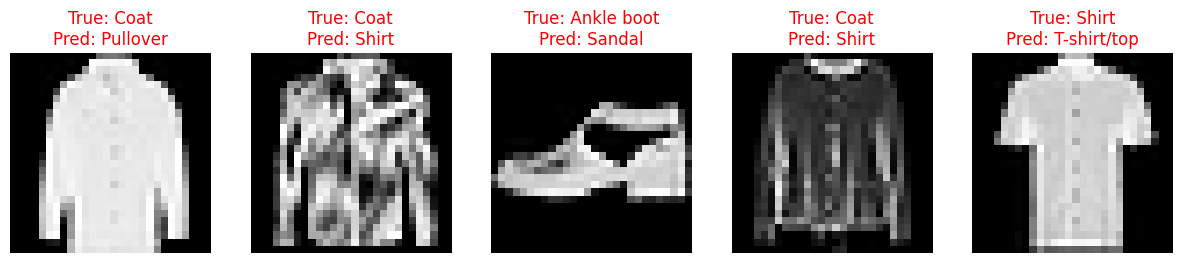

In [69]:
plt.figure(figsize=(15,6))
num_images_to_show = 5
for i in range (num_images_to_show):
  # Move the image tensor to CPU before plotting
  image = misclassified_images[i].squeeze().cpu()
  true_label = misclassified_labels[i]
  pred_label = misclassified_preds[i]

  plt.subplot(1, num_images_to_show, i+1)
  plt.imshow(image, cmap="gray")
  plt.axis("off")
  plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
        color="red"
    )
plt.show()

* After visualing these predictions do you think it's more of a modelling error or a data error?
   FashionMNIST has label overlap

  Some classes are extremely similar visually:

> Shirt vs T-shirt/top

> Coat vs Pullover

> Coat vs Shirt


* As in, could the model do better  or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?
mostlty a data error(dataset ambiguity)
because: FashionMNIST is known for:

* Visually similar categories

* Low-resolution images (28×28)

* Clothes with nearly identical shapes

As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?
the model can improve but only to a limit Using:

* Better architecture (CNN instead of simple FC layers)

* Data augmentation

* run More epochs